# LAB AI

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data-bank.csv')
target_col = 'Bankrupt?'

print("Data Loaded. Shape:", df.shape)

Data Loaded. Shape: (6819, 96)


In [25]:
X = df.drop(target_col, axis=1)
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Training Shape:", X_train_scaled.shape)
print("Data Testing Shape:", X_test_scaled.shape)

Data Training Shape: (5455, 95)
Data Testing Shape: (1364, 95)


In [26]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'SVM': SVC(random_state=42, class_weight='balanced', probability=True),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gaussian Naive Bayes': GaussianNB()
}

In [27]:
results = {}

print("Mulai Training Base Models dengan SMOTE...\n")

for name, model in models.items():
    try:
        pipeline = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])

        # Training
        pipeline.fit(X_train_scaled, y_train)

        # Prediction
        y_pred = pipeline.predict(X_test_scaled)

        # Hitung Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        # Hitung Precision per Class secara manual dari Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        # CM structure: [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = cm.ravel()

        # Precision 0 (Sehat) = TN / (TN + FN)
        prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0

        # Precision 1 (Bangkrut) = TP / (TP + FP)
        prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0

        results[name] = {
            'Model': name,
            'Accuracy': acc,
            'F1-Score': f1,
            'Recall': recall,
            'Precision_0': prec_0,
            'Precision_1': prec_1,
            'Object': pipeline # Simpan objek model untuk dipakai nanti
        }

        print(f"Selesai: {name}")

    except Exception as e:
        print(f"Error pada {name}: {e}")

results_df = pd.DataFrame(results.values())

print("\n" + "="*60)
print("HASIL EVALUASI BASE MODELS (Diurutkan by F1-Score)")
print("="*60)
display_cols = ['Model', 'Accuracy', 'F1-Score', 'Recall', 'Precision_0', 'Precision_1']
print(results_df[display_cols].sort_values(by='F1-Score', ascending=False).to_string(index=False))

Mulai Training Base Models dengan SMOTE...

Selesai: Random Forest
Selesai: Logistic Regression
Selesai: SVM
Selesai: Gradient Boosting
Selesai: XGBoost
Selesai: LightGBM
Selesai: AdaBoost
Selesai: K-Nearest Neighbors
Selesai: Decision Tree
Selesai: Extra Trees
Selesai: Gaussian Naive Bayes

HASIL EVALUASI BASE MODELS (Diurutkan by F1-Score)
               Model  Accuracy  F1-Score   Recall  Precision_0  Precision_1
            LightGBM  0.966276  0.520833 0.568182     0.985518     0.480769
       Random Forest  0.959677  0.485981 0.590909     0.986164     0.412698
             XGBoost  0.963343  0.479167 0.522727     0.983994     0.442308
         Extra Trees  0.959677  0.432990 0.477273     0.982456     0.396226
   Gradient Boosting  0.938416  0.416667 0.681818     0.988924     0.300000
            AdaBoost  0.917889  0.348837 0.681818     0.988673     0.234375
       Decision Tree  0.940616  0.330579 0.454545     0.981352     0.259740
 Logistic Regression  0.884164  0.300885 0.77272

In [28]:
top_5_names = results_df.sort_values(by='F1-Score', ascending=False).head(5)['Model'].tolist()
print(f"\nTop 5 Model Terpilih: {top_5_names}")

param_grids = {
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 20, None]},
    'XGBoost': {'classifier__learning_rate': [0.01, 0.1], 'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5]},
    'LightGBM': {'classifier__learning_rate': [0.01, 0.1], 'classifier__n_estimators': [100, 200], 'classifier__num_leaves': [31, 50]},
    'Gradient Boosting': {'classifier__learning_rate': [0.01, 0.1], 'classifier__n_estimators': [100, 200]},
    'Extra Trees': {'classifier__n_estimators': [100, 200], 'classifier__min_samples_split': [2, 5]},
    'AdaBoost': {'classifier__n_estimators': [50, 100], 'classifier__learning_rate': [0.01, 0.1]},
    'Logistic Regression': {'classifier__C': [0.1, 1, 10]},
    'SVM': {'classifier__C': [1, 10], 'classifier__kernel': ['rbf']},
    'K-Nearest Neighbors': {'classifier__n_neighbors': [3, 5, 7]},
    'Decision Tree': {'classifier__max_depth': [10, 20, None]}
}

tuned_results = []

print("\nMulai Hyperparameter Tuning untuk Top 5...")

for name in top_5_names:
    print(f"  Sedang tuning {name}...")

    base_model = models[name]

    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', base_model)
    ])

    if name in param_grids:
        grid = param_grids[name]

        search = RandomizedSearchCV(
            pipeline,
            grid,
            n_iter=5,
            scoring='f1',
            cv=3,
            random_state=42,
            n_jobs=-1
        )

        search.fit(X_train_scaled, y_train)
        best_model = search.best_estimator_
    else:
        print(f"    Grid tidak ditemukan untuk {name}, menggunakan model default.")
        pipeline.fit(X_train_scaled, y_train)
        best_model = pipeline

    # Evaluasi Model Hasil Tuning
    y_pred = best_model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
    prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0

    tuned_results.append({
        'Model': name + " (Tuned)",
        'Accuracy': acc,
        'F1-Score': f1,
        'Recall': recall,
        'Precision_0': prec_0,
        'Precision_1': prec_1
    })

# Tampilkan Hasil Akhir Tuning
tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-Score', ascending=False)
print("\n" + "="*60)
print("HASIL AKHIR SETELAH TUNING (TOP 5)")
print("="*60)
print(tuned_df.to_string(index=False))


Top 5 Model Terpilih: ['LightGBM', 'Random Forest', 'XGBoost', 'Extra Trees', 'Gradient Boosting']

Mulai Hyperparameter Tuning untuk Top 5...
  Sedang tuning LightGBM...
  Sedang tuning Random Forest...
  Sedang tuning XGBoost...
  Sedang tuning Extra Trees...
  Sedang tuning Gradient Boosting...

HASIL AKHIR SETELAH TUNING (TOP 5)
                    Model  Accuracy  F1-Score   Recall  Precision_0  Precision_1
          XGBoost (Tuned)  0.965543  0.515464 0.568182     0.985507     0.471698
    Random Forest (Tuned)  0.960411  0.500000 0.613636     0.986923     0.421875
         LightGBM (Tuned)  0.964076  0.484211 0.522727     0.984006     0.450980
Gradient Boosting (Tuned)  0.952346  0.471545 0.659091     0.988327     0.367089
      Extra Trees (Tuned)  0.961877  0.458333 0.500000     0.983232     0.423077


In [31]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score, precision_score
import pandas as pd
import numpy as np

def print_comprehensive_evaluation(models, top_model_names, X_test, y_test):
    print("="*80)
    print("EVALUASI KOMPREHENSIF MODEL BANKRUPTCY PREDICTION")
    print("="*80)

    final_comparison = []

    for name in top_model_names:
        model = models[name]

        try:
            y_pred = model.predict(X_test)
        except:
            print(f"[WARNING] Model {name} belum di-fit atau struktur berbeda.")
            continue

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity
        prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
        fnr_1 = fn / (tp + fn) if (tp + fn) > 0 else 0     # False Negative Rate (Risiko Fatal)

        prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr_0 = fp / (tn + fp) if (tn + fp) > 0 else 0     # False Positive Rate (Alarm Palsu)

        final_comparison.append({
            'Model': name,
            'Accuracy': acc,
            'F1-Score': f1,
            'Precision_1': prec_1,
            'Recall_1': recall_1,
            'Precision_0': prec_0,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
            'False_Negative_Rate': fnr_1,
            'False_Positive_Rate': fpr_0
        })

        # ==========================================
        # TABEL REPORT PER MODEL
        # ==========================================
        print(f"\n{'='*60}")
        print(f"EVALUASI {name.upper()}")
        print(f"{'='*60}")

        print(f"Confusion Matrix (shape: {cm.shape}):")
        print(cm)
        print("")
        print(f"{'':<20} {'Predicted 0':<15} {'Predicted 1':<15}")
        print(f"{'Actual 0 (Sehat)':<20} {tn:<5} (TN) {fp:>10} (FP)")
        print(f"{'Actual 1 (Bangkrut)':<20} {fn:<5} (FN) {tp:>10} (TP)")

        print("\nMETRIC PERFORMANCE:")
        print(f"{'Accuracy:':<20} {acc:.4f}")
        print(f"{'F1-Score:':<20} {f1:.4f}")

        print("\nKELAS 1 - BANKRUPT (Positive):")
        print(f"{'Precision:':<20} {prec_1:.4f}  → Dari yg diprediksi bangkrut, {prec_1*100:.1f}% benar bangkrut")
        print(f"{'Recall (Sens):':<20} {recall_1:.4f}  → Dari yg benar bangkrut, {recall_1*100:.1f}% terdeteksi")
        print(f"{'False Neg Rate:':<20} {fnr_1:.4f}  → {fnr_1*100:.1f}% bangkrut TIDAK terdeteksi (RISIKO TINGGI)")

        print("\nKELAS 0 - SEHAT (Negative):")
        print(f"{'Precision:':<20} {prec_0:.4f}  → Dari yg diprediksi sehat, {prec_0*100:.1f}% benar sehat")
        print(f"{'Specificity:':<20} {specificity:.4f}  → Dari yg benar sehat, {specificity*100:.1f}% terdeteksi sehat")
        print(f"{'False Pos Rate:':<20} {fpr_0:.4f}  → {fpr_0*100:.1f}% sehat dikira bangkrut (Biaya Audit Sia-sia)")

        print("\nBUSINESS IMPACT ANALYSIS:")
        total_test = len(y_test)
        total_bangkrut = sum(y_test)
        total_sehat = total_test - total_bangkrut
        print(f"Total Sample Test:    {total_test}")
        print(f"Perusahaan Bangkrut:  {total_bangkrut} ({(total_bangkrut/total_test)*100:.1f}%)")
        print(f"Perusahaan Sehat:     {total_sehat} ({(total_sehat/total_test)*100:.1f}%)")

        print("\nRISIKO REAL:")
        print(f"- Perusahaan bangkrut yg LOLOS (Gagal Deteksi): {fn} perusahaan")
        print(f"- Perusahaan sehat yg dicurigai (Salah Tuduh):  {fp} perusahaan")

        print("\n📋 CLASSIFICATION REPORT:")
        print(classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Bangkrut (1)']))

    # ==========================================
    # TABEL PERBANDINGAN AKHIR
    # ==========================================
    df_comp = pd.DataFrame(final_comparison).sort_values(by='F1-Score', ascending=False)

    print("\n" + "="*80)
    print("PERBANDINGAN SEMUA MODEL TERBAIK")
    print("="*80)
    # Mengatur opsi display pandas agar kolom tidak terpotong
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print(df_comp.round(4).to_string(index=False))

    best_model = df_comp.iloc[0]
    print("\n" + "="*80)
    print("SUMMARY REKOMENDASI FINAL")
    print("="*80)
    print(f"🏆 MODEL TERBAIK: {best_model['Model']}")
    print(f"📈 F1-Score: {best_model['F1-Score']:.4f}")
    print(f"🎯 Recall Bangkrut: {best_model['Recall_1']:.4f} (Mendeteksi {int(best_model['Recall_1']*100)}% kasus bangkrut)")
    print(f"✅ Precision Bangkrut: {best_model['Precision_1']:.4f}")
    print(f"⚠️ Catatan: Model ini melewatkan {int(best_model['FN'])} perusahaan bangkrut dari total {int(best_model['TP']+best_model['FN'])} kasus.")

print_comprehensive_evaluation(models, top_5_names, X_test_scaled, y_test)


EVALUASI KOMPREHENSIF MODEL BANKRUPTCY PREDICTION

EVALUASI LIGHTGBM
Confusion Matrix (shape: (2, 2)):
[[1293   27]
 [  19   25]]

                     Predicted 0     Predicted 1    
Actual 0 (Sehat)     1293  (TN)         27 (FP)
Actual 1 (Bangkrut)  19    (FN)         25 (TP)

METRIC PERFORMANCE:
Accuracy:            0.9663
F1-Score:            0.5208

KELAS 1 - BANKRUPT (Positive):
Precision:           0.4808  → Dari yg diprediksi bangkrut, 48.1% benar bangkrut
Recall (Sens):       0.5682  → Dari yg benar bangkrut, 56.8% terdeteksi
False Neg Rate:      0.4318  → 43.2% bangkrut TIDAK terdeteksi (RISIKO TINGGI)

KELAS 0 - SEHAT (Negative):
Precision:           0.9855  → Dari yg diprediksi sehat, 98.6% benar sehat
Specificity:         0.9795  → Dari yg benar sehat, 98.0% terdeteksi sehat
False Pos Rate:      0.0205  → 2.0% sehat dikira bangkrut (Biaya Audit Sia-sia)

BUSINESS IMPACT ANALYSIS:
Total Sample Test:    1364
Perusahaan Bangkrut:  44 (3.2%)
Perusahaan Sehat:     1320 (96.8%)

EVALUASI KOMPREHENSIF MODEL BANKRUPTCY PREDICTION

EVALUASI LIGHTGBM
Confusion Matrix (shape: (2, 2)):
[[1293   27]
 [  19   25]]

                     Predicted 0     Predicted 1    
Actual 0 (Sehat)     1293  (TN)         27 (FP)
Actual 1 (Bangkrut)  19    (FN)         25 (TP)

METRIC PERFORMANCE:
Accuracy:            0.9663
F1-Score:            0.5208

KELAS 1 - BANKRUPT (Positive):
Precision:           0.4808  → Dari yg diprediksi bangkrut, 48.1% benar bangkrut
Recall (Sens):       0.5682  → Dari yg benar bangkrut, 56.8% terdeteksi
False Neg Rate:      0.4318  → 43.2% bangkrut TIDAK terdeteksi (RISIKO TINGGI)

KELAS 0 - SEHAT (Negative):
Precision:           0.9855  → Dari yg diprediksi sehat, 98.6% benar sehat
Specificity:         0.9795  → Dari yg benar sehat, 98.0% terdeteksi sehat
False Pos Rate:      0.0205  → 2.0% sehat dikira bangkrut (Biaya Audit Sia-sia)

BUSINESS IMPACT ANALYSIS:
Total Sample Test:    1364
Perusahaan Bangkrut:  44 (3.2%)
Perusahaan Sehat:     1320 (96.8%)

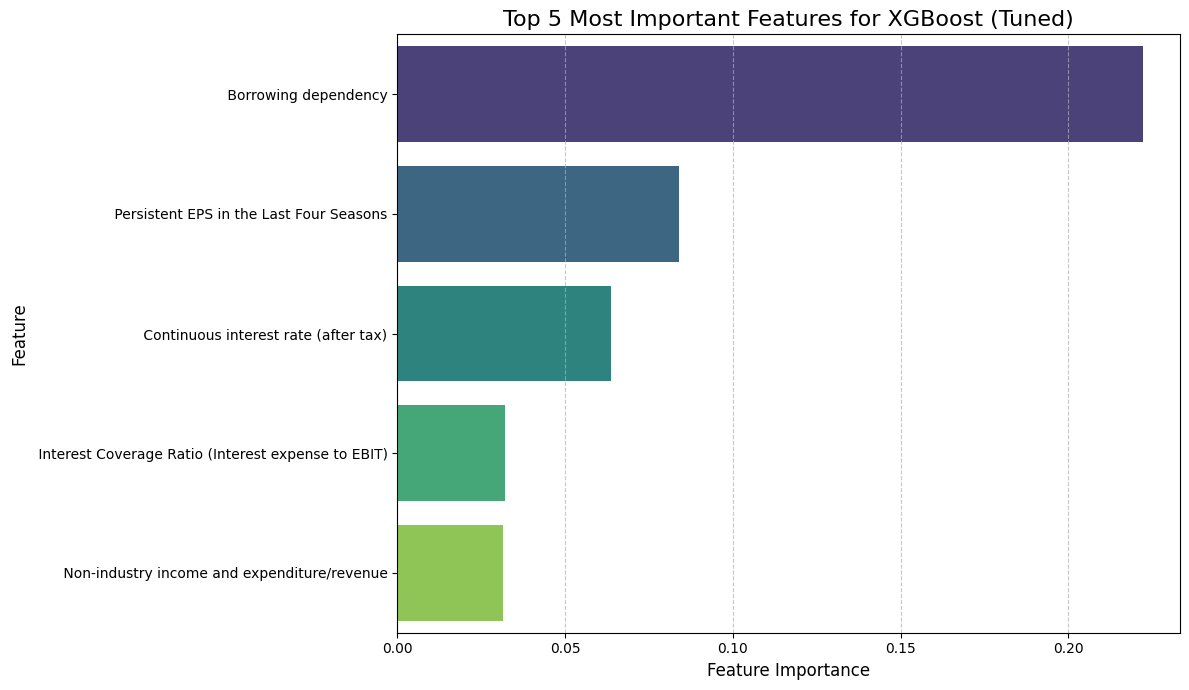

In [47]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score, precision_score
import pandas as pd
import numpy as np

def print_comprehensive_evaluation(models, top_model_names, X_test, y_test):
    print("="*80)
    print("EVALUASI KOMPREHENSIF MODEL BANKRUPTCY PREDICTION")
    print("="*80)

    final_comparison = []

    for name in top_model_names:
        model = models[name]

        try:
            y_pred = model.predict(X_test)
        except:
            print(f"[WARNING] Model {name} belum di-fit atau struktur berbeda.")
            continue

        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity
        prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
        fnr_1 = fn / (tp + fn) if (tp + fn) > 0 else 0     # False Negative Rate (Risiko Fatal)

        prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr_0 = fp / (tn + fp) if (tn + fp) > 0 else 0     # False Positive Rate (Alarm Palsu)

        final_comparison.append({
            'Model': name,
            'Accuracy': acc,
            'F1-Score': f1,
            'Precision_1': prec_1,
            'Recall_1': recall_1,
            'Precision_0': prec_0,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
            'False_Negative_Rate': fnr_1,
            'False_Positive_Rate': fpr_0
        })

        # ==========================================
        # TABEL REPORT PER MODEL
        # ==========================================
        print(f"\n{'='*60}")
        print(f"EVALUASI {name.upper()}")
        print(f"{'='*60}")

        print(f"Confusion Matrix (shape: {cm.shape}):")
        print(cm)
        print("")
        print(f"{'':<20} {'Predicted 0':<15} {'Predicted 1':<15}")
        print(f"{'Actual 0 (Sehat)':<20} {tn:<5} (TN) {fp:>10} (FP)")
        print(f"{'Actual 1 (Bangkrut)':<20} {fn:<5} (FN) {tp:>10} (TP)")

        print("\nMETRIC PERFORMANCE:")
        print(f"{'Accuracy:':<20} {acc:.4f}")
        print(f"{'F1-Score:':<20} {f1:.4f}")

        print("\nKELAS 1 - BANKRUPT (Positive):")
        print(f"{'Precision:':<20} {prec_1:.4f}  → Dari yg diprediksi bangkrut, {prec_1*100:.1f}% benar bangkrut")
        print(f"{'Recall (Sens):':<20} {recall_1:.4f}  → Dari yg benar bangkrut, {recall_1*100:.1f}% terdeteksi")
        print(f"{'False Neg Rate:':<20} {fnr_1:.4f}  → {fnr_1*100:.1f}% bangkrut TIDAK terdeteksi (RISIKO TINGGI)")

        print("\nKELAS 0 - SEHAT (Negative):")
        print(f"{'Precision:':<20} {prec_0:.4f}  → Dari yg diprediksi sehat, {prec_0*100:.1f}% benar sehat")
        print(f"{'Specificity:':<20} {specificity:.4f}  → Dari yg benar sehat, {specificity*100:.1f}% terdeteksi sehat")
        print(f"{'False Pos Rate:':<20} {fpr_0:.4f}  → {fpr_0*100:.1f}% sehat dikira bangkrut (Biaya Audit Sia-sia)")

        print("\nBUSINESS IMPACT ANALYSIS:")
        total_test = len(y_test)
        total_bangkrut = sum(y_test)
        total_sehat = total_test - total_bangkrut
        print(f"Total Sample Test:    {total_test}")
        print(f"Perusahaan Bangkrut:  {total_bangkrut} ({(total_bangkrut/total_test)*100:.1f}%)")
        print(f"Perusahaan Sehat:     {total_sehat} ({(total_sehat/total_test)*100:.1f}%)")

        print("\nRISIKO REAL:")
        print(f"- Perusahaan bangkrut yg LOLOS (Gagal Deteksi): {fn} perusahaan")
        print(f"- Perusahaan sehat yg dicurigai (Salah Tuduh):  {fp} perusahaan")

        print("\n📋 CLASSIFICATION REPORT:")
        print(classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Bangkrut (1)']))

    # ==========================================
    # TABEL PERBANDINGAN AKHIR
    # ==========================================
    df_comp = pd.DataFrame(final_comparison).sort_values(by='F1-Score', ascending=False)

    print("\n" + "="*80)
    print("PERBANDINGAN SEMUA MODEL TERBAIK")
    print("="*80)
    # Mengatur opsi display pandas agar kolom tidak terpotong
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print(df_comp.round(4).to_string(index=False))

    best_model = df_comp.iloc[0]
    print("\n" + "="*80)
    print("SUMMARY REKOMENDASI FINAL")
    print("="*80)
    print(f"🏆 MODEL TERBAIK: {best_model['Model']}")
    print(f"📈 F1-Score: {best_model['F1-Score']:.4f}")
    print(f"🎯 Recall Bangkrut: {best_model['Recall_1']:.4f} (Mendeteksi {int(best_model['Recall_1']*100)}% kasus bangkrut)")
    print(f"✅ Precision Bangkrut: {best_model['Precision_1']:.4f}")
    print(f"⚠️ Catatan: Model ini melewatkan {int(best_model['FN'])} perusahaan bangkrut dari total {int(best_model['TP']+best_model['FN'])} kasus.")

print_comprehensive_evaluation(models, top_5_names, X_test_scaled, y_test)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

# Sort the tuned_df by F1-Score in descending order and get the name of the top model
best_tuned_model_name_with_suffix = tuned_df.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model_base_name = best_tuned_model_name_with_suffix.replace(' (Tuned)', '')

print(f"Identified Best Tuned Model (by F1-Score): {best_model_base_name}")

# 2. Retrieve Best Tuned Model Object
# Since the tuned model objects were not explicitly stored with their hyperparameters,
# we need to re-run RandomizedSearchCV for the identified best model.

# Access the original base model from the 'models' dictionary
base_model = models[best_model_base_name]

# Access the corresponding parameter grid from 'param_grids'
param_grid = param_grids[best_model_base_name]

# Create the pipeline as it was used during the tuning phase (SMOTE + Classifier)
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', base_model)
])

# Re-run RandomizedSearchCV to get the `best_estimator_` (the tuned pipeline)
print(f"Re-running RandomizedSearchCV for {best_model_base_name} to retrieve the exact best pipeline configuration...")

search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=5,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_scaled, y_train)
best_pipeline = search.best_estimator_

print("Best pipeline retrieved successfully.")


classifier = best_pipeline.named_steps['classifier']


if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):

    importances = np.abs(classifier.coef_[0])
else:
    print(f"Warning: Classifier {type(classifier).__name__} does not have 'feature_importances_' or 'coef_'.")
    print("Cannot extract feature importances directly. Skipping feature importance analysis.")
    importances = None

if importances is not None:
    feature_names = X.columns
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("\nTop 10 Feature Importances:")
    print(feature_importance_df.head(10).to_string(index=False))

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(5), palette='viridis')
    plt.title(f'Top 5 Most Important Features for {best_model_base_name} (Tuned)', fontsize=16)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [50]:
top_5_features = feature_importance_df.head(5)
print("\n" + "="*80)
print(f"ANALYSIS OF TOP 5 MOST INFLUENTIAL VARIABLES FOR BANKRUPTCY PREDICTION (Model: {best_model_base_name} Tuned)")
print("="*80)
print("Based on the best-performing model, the top 5 most influential variables are:")
for index, row in top_5_features.iterrows():
    print(f"- {row['Feature']}: Importance = {row['Importance']:.4f}")



ANALYSIS OF TOP 5 MOST INFLUENTIAL VARIABLES FOR BANKRUPTCY PREDICTION (Model: XGBoost Tuned)
Based on the best-performing model, the top 5 most influential variables are:
-  Borrowing dependency: Importance = 0.2221
-  Persistent EPS in the Last Four Seasons: Importance = 0.0839
-  Continuous interest rate (after tax): Importance = 0.0636
-  Interest Coverage Ratio (Interest expense to EBIT): Importance = 0.0322
-  Non-industry income and expenditure/revenue: Importance = 0.0315
